# Script to estimate airborne fraction trends with all LULC measurement

combinations

Fossil emissions and atmospheric growth from GCB 2025 with LULC panel measurements

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

This script estimates airborne-fraction trends using the GCB 2025 fossil-emissions and atmospheric-growth series together with all LULC measurement combinations produced by the LULC extraction script. The LULC panel includes the extracted bookkeeping series and all peat-augmented model combinations. We use the cross-measurement dispersion of that full LULC panel to construct delta-method weights, then replicate the OLS and WLS trend analysis for the full sample and for the sample ending in 2023.

## Script to run the mixes model analysis

Load the dataset and the LULC measurement panel.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
using Statistics
include(joinpath(@__DIR__, "estimation_functions.jl"))

dataframe_to_markdown_table (generic function with 1 method)

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
lulc_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")

gcb_df = CSV.read(data_path, DataFrame)
lulc_df = CSV.read(lulc_path, DataFrame)
rename!(lulc_df, :year => :Year);

## Full sample

### Build the airborne-fraction series

Transform to panel format and compute the AF series for each LULC measurement combination.

In [1]:
long_df = build_panel_dataset(gcb_df, lulc_df)

### Fit the mixed model

In [1]:
mmodel = fit_mixed_model(long_df)

  ------------- -------- -------- ------- --------- --------------
                    Est.       SE       z         p   σ_definition
  (Intercept)     0.4070   0.0056   73.02   \<1e-99         0.0352
  t               0.0011   0.0001   10.80   \<1e-26         0.0003
  Residual        0.1237                            
  ------------- -------- -------- ------- --------- --------------


Report the results of the mixed model estimation.

In [1]:
group_df = extract_group_coefficients(mmodel, long_df)

In [1]:
summary_df = summarize_population_effects(mmodel, group_df)

### Plotting the mixed model results


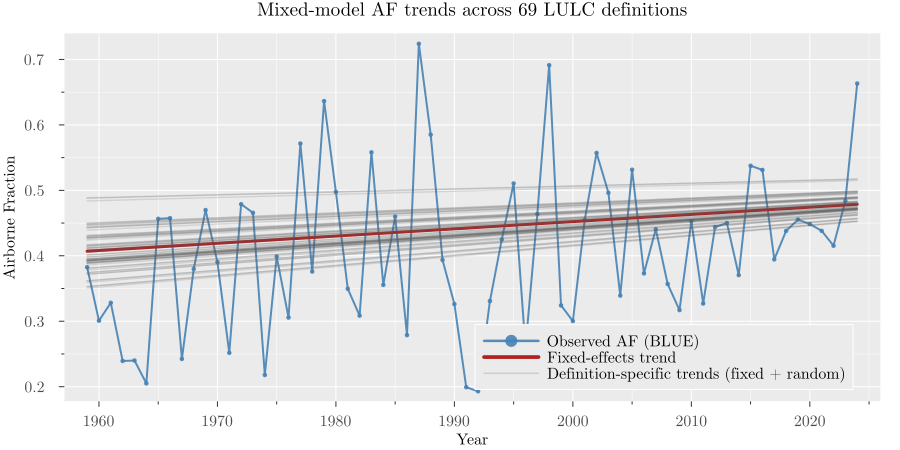

In [1]:
using Plots.PlotMeasures
years = sort(unique(long_df.Year))
t_vals = years .- minimum(years)

# Choose one observed AF definition to overlay for perspective.
overlay_def = first(group_df.definition)
overlay_df = long_df[long_df.definition .== overlay_def, [:Year, :AF]]

p_mm = plot(
    title = "Mixed-model AF trends across 69 LULC definitions",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (900, 450),
    margin = 3mm,
    legend = :topleft,
)


# Overlay one observed AF series for context.
plot!(
    p_mm,
    overlay_df.Year,
    overlay_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    linestyle = :solid,
    marker = :circle,
    markersize = 2.5,
    alpha = 0.9,
    label = "Observed AF ($(overlay_def))",
)

# Plot fixed-effects trend as a solid highlighted line.
yhat_fixed = summary_df.mu_alpha[1] .+ summary_df.mu_beta[1] .* t_vals
plot!(
    p_mm,
    years,
    yhat_fixed;
    color = :firebrick,
    linewidth = 3.0,
    linestyle = :solid,
    label = "Fixed-effects trend",
    legend = :bottomright,
    legendfontsize = 10
)

# Plot 69 definition-specific lines: fixed + random effects (translucent).
for (j, r) in enumerate(eachrow(group_df))
    alpha_j = r.alpha_j
    beta_j = r.beta_j
    yhat_j = alpha_j .+ beta_j .* t_vals
    plot!(
        p_mm,
        years,
        yhat_j;
        color = :gray35,
        alpha = 0.18,
        linewidth = 1.4,
        linestyle = :solid,
        label = (j == 1 ? "Definition-specific trends (fixed + random)" : nothing),
    )
end

p_mm

Save the mixed model plot.

In [1]:
savefig(p_mm, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends.png"))
savefig(p_mm, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_mixed_model_definition_trends.pdf"

## Subsample up to 2023

In [1]:
long_df_2023 = filter(row -> row.Year <= 2023, long_df)

Fit the mixed model to the subsample.

In [1]:
mmodel_2023 = fit_mixed_model(long_df_2023)

  ------------- -------- -------- ------- --------- --------------
                    Est.       SE       z         p   σ_definition
  (Intercept)     0.4133   0.0056   73.98   \<1e-99         0.0355
  t               0.0008   0.0001    7.82   \<1e-14         0.0003
  Residual        0.1218                            
  ------------- -------- -------- ------- --------- --------------


Report the results of the mixed model estimation for the subsample.

In [1]:
group_df_2023 = extract_group_coefficients(mmodel_2023, long_df_2023)
summary_df_2023 = summarize_population_effects(mmodel_2023, group_df_2023)

Plot the mixed model results for the subsample.


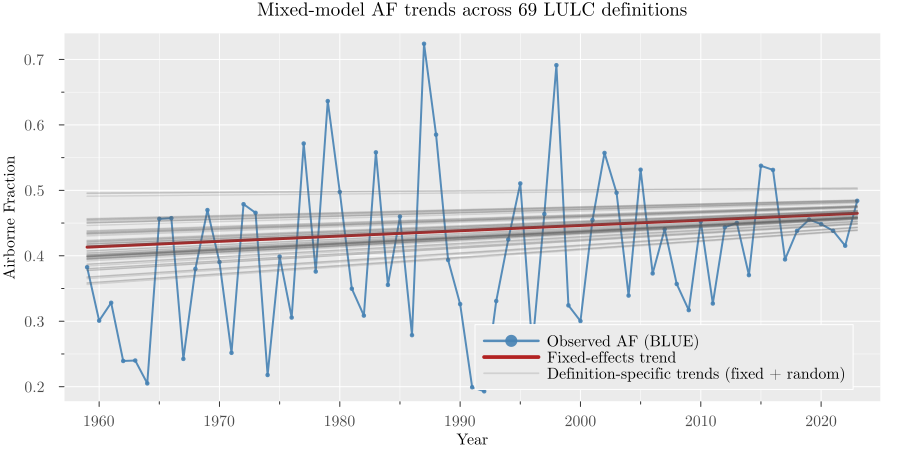

In [1]:
years_2023 = sort(unique(long_df_2023.Year))
t_vals = years_2023 .- minimum(years_2023)

# Choose one observed AF definition to overlay for perspective.
overlay_def = first(group_df_2023.definition)
overlay_df = long_df_2023[long_df_2023.definition .== overlay_def, [:Year, :AF]]

p_mm_2023 = plot(
    title = "Mixed-model AF trends across 69 LULC definitions",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (900, 450),
    margin = 3mm,
    legend = :topleft,
)


# Overlay one observed AF series for context.
plot!(
    p_mm_2023,
    overlay_df.Year,
    overlay_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    linestyle = :solid,
    marker = :circle,
    markersize = 2.5,
    alpha = 0.9,
    label = "Observed AF ($(overlay_def))",
)

# Plot fixed-effects trend as a solid highlighted line.
yhat_fixed = summary_df_2023.mu_alpha[1] .+ summary_df_2023.mu_beta[1] .* t_vals
plot!(
    p_mm_2023,
    years_2023,
    yhat_fixed;
    color = :firebrick,
    linewidth = 3.0,
    linestyle = :solid,
    label = "Fixed-effects trend",
    legend = :bottomright,
    legendfontsize = 10
)

# Plot 69 definition-specific lines: fixed + random effects (translucent).
for (j, r) in enumerate(eachrow(group_df_2023))
    alpha_j = r.alpha_j
    beta_j = r.beta_j
    yhat_j = alpha_j .+ beta_j .* t_vals
    plot!(
        p_mm_2023,
        years_2023,
        yhat_j;
        color = :gray35,
        alpha = 0.18,
        linewidth = 1.4,
        linestyle = :solid,
        label = (j == 1 ? "Definition-specific trends (fixed + random)" : nothing),
    )
end

p_mm_2023

In [1]:
savefig(p_mm_2023, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_up_to_2023.png"))
savefig(p_mm_2023, joinpath(@__DIR__, "..", "figures", "AF_mixed_model_definition_trends_up_to_2023.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_mixed_model_definition_trends_up_to_2023.pdf"

## Results

### Fixed-effects summary (mixed models)

In [1]:
#| results: asis
mixed_results_table = build_mixed_fixed_effects_summary_table(mmodel, long_df, mmodel_2023, long_df_2023)
mixed_table_md = dataframe_to_markdown_table(mixed_results_table)

println(mixed_table_md)

mixed_out_path = joinpath(@__DIR__, "..", "results", "af_mixed_model_fixed_effects_summary_table.md")
open(mixed_out_path, "w") do io
    write(io, mixed_table_md)
end

println("Saved mixed-model summary table to: $(mixed_out_path)")

| Metric | Intercept (full) | Slope (full) | Intercept (up to 2023) | Slope (up to 2023) |
|---|---:|---:|---:|---:|
| Estimate | 0.406959 | 0.001103 | 0.41326 | 0.000808 |
| Standard error | 0.005573 | 0.000102 | 0.005586 | 0.000103 |
| p-value | 0.0 | 0.0 | 0.0 | 0.0 |
| R-squared (marginal) | 0.008631 | 0.008631 | 0.004518 | 0.004518 |
| R-squared (conditional) | 0.700967 | 0.700967 | 0.708173 | 0.708173 |

Saved mixed-model summary table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_mixed_model_fixed_effects_summary_table.md